# 1. Import das bibliotecas necessárias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# 2. Carregamento dos dados

### Sobre o dataset

#### Contexto
Uma empresa fictícia de telecomunicações que forneceu serviços de telefonia fixa e internet para 7.043 clientes na Califórnia no terceiro trimestre.

##### Esquema de variáveis (conforme o kaggle)

- ID do cliente : Um ID exclusivo que identifica cada cliente.

- Contagem : Um valor usado em relatórios/painéis para somar o número de clientes em um conjunto filtrado.

- País : O país de residência principal do cliente.

- Estado : O estado da residência principal do cliente.

- Cidade : A cidade da residência principal do cliente.

- CEP : O CEP da residência principal do cliente.

- Lat Long : A combinação da latitude e longitude da residência principal do cliente.

- Latitude : A latitude da residência principal do cliente.

- Longitude : A longitude da residência principal do cliente.

- Gênero : O gênero do cliente: Masculino, Feminino

- Idoso : Indica se o cliente tem 65 anos ou mais: Sim, Não

- Parceiro : Indique se o cliente tem um parceiro: Sim, Não

- Dependentes : Indica se o cliente mora com algum dependente: Sim, Não. Dependentes podem ser filhos, pais, avós, etc.

- Tempo de permanência no relacionamento : Indica o número total de meses que o cliente permaneceu com a empresa até o final do trimestre especificado acima.

- Serviço Telefônico : Indica se o cliente possui assinatura de serviço de telefonia fixa com a empresa: Sim, Não

- Linhas Múltiplas : Indica se o cliente possui várias linhas telefônicas com a empresa: Sim, Não

- Serviço de Internet : Indica se o cliente possui assinatura de serviço de Internet com a empresa: Não, DSL, Fibra Óptica, Cabo.

- Segurança online : Indica se o cliente subscreve um serviço adicional de segurança online fornecido pela empresa: Sim, Não

- Backup online : Indica se o cliente subscreve um serviço adicional de backup online fornecido pela empresa: Sim, Não

- Proteção do dispositivo : Indica se o cliente subscreveu um plano adicional de proteção para o seu equipamento de Internet fornecido pela empresa: Sim, Não

- Suporte técnico : Indica se o cliente subscreveu um plano adicional de suporte técnico da empresa com tempos de espera reduzidos: Sim, Não

- Streaming de TV : Indica se o cliente utiliza seu serviço de internet para assistir a programas de televisão de um provedor terceirizado: Sim, Não. A empresa não cobra nenhuma taxa adicional por este serviço.

- Streaming de filmes : Indica se o cliente utiliza seu serviço de internet para assistir a filmes de um provedor terceirizado: Sim, Não. A empresa não cobra nenhuma taxa adicional por este serviço.

- Contrato : Indica o tipo de contrato atual do cliente: Mensal, Anual ou Bienal.

- Fatura eletrônica : Indica se o cliente optou pela fatura eletrônica: Sim, Não

- Método de pagamento : Indica como o cliente pagará sua conta: Débito bancário, Cartão de crédito, Cheque enviado pelo correio

- Cobrança mensal : Indica o valor total cobrado mensalmente pelo cliente por todos os serviços prestados pela empresa.

- Total de Cobranças : Indica o total de cobranças do cliente, calculado até o final do trimestre especificado acima.

- Rótulo de Churn : Sim = o cliente deixou a empresa neste trimestre. Não = o cliente permaneceu com a empresa. Diretamente relacionado ao Valor do Churn.

- Valor de Churn : 1 = o cliente deixou a empresa neste trimestre. 0 = o cliente permaneceu com a empresa. Diretamente relacionado ao Rótulo de Churn.

- Churn Score : Um valor de 0 a 100 calculado usando a ferramenta preditiva IBM SPSS Modeler. O modelo incorpora múltiplos fatores conhecidos por causarem churn. Quanto maior a pontuação, maior a probabilidade de o cliente cancelar o serviço.

- CLTV : Valor do Tempo de Vida do Cliente. O CLTV previsto é calculado usando fórmulas corporativas e dados existentes. Quanto maior o valor, mais valioso o cliente. Clientes de alto valor devem ser monitorados quanto à possibilidade de cancelamento (churn).

- Motivo do Cancelamento : A razão específica pela qual um cliente deixou a empresa. Diretamente relacionado à Categoria de Cancelamento.

In [3]:
# Carregando o dataset para o repositório

path = '../data/raw/Telco_customer_churn.xlsx'

df = pd.read_excel(path)

In [4]:
df.rename(columns={
            'CustomerID': 'customer_id',
            'Count': 'count',	
            'Country': 'country',	
            'State': 'state',
            'City': 'city',
            'Zip Code': 'zip_code',
            'Lat Long': 'lat_long',
            'Latitude': 'latitude',
            'Longitude': 'longitude',	
            'Gender': 'gender',
            'Senior Citizen': 'senior_citizen',
            'Partner': 'partner',	
            'Dependents': 'dependents',	
            'Tenure Months': 'tenure_months',	
            'Phone Service': 'phone_service',	
            'Multiple Lines': 'multiple_lines',	
            'Internet Service': 'internet_service',	
            'Online Security': 'online_security',	
            'Online Backup': 'online_backup',	
            'Device Protection': 'device_protection',	
            'Tech Support': 'tech_support',	
            'Streaming TV': 'streaming_tv',	
            'Streaming Movies': 'streaming_movies',	
            'Contract': 'contract',	
            'Paperless Billing': 'paperless_billing',	
            'Payment Method': 'payment_method',
            'Monthly Charges': 'monthly_charges',	
            'Total Charges': 'total_charges',	
            'Churn Label': 'churn_label',	
            'Churn Value': 'churn_value',	
            'Churn Score': 'churn_score',	
            'CLTV': 'cltv',	
            'Churn Reason': 'churn_reason'},
            inplace=True
)

In [5]:
# Verificação do nível de balanceamento da base de dados
print(f"Balanceamento de classes: {df['churn_value'].value_counts()}")

Balanceamento de classes: churn_value
0    5174
1    1869
Name: count, dtype: int64


In [78]:

print(f"=========== Primeiras análises sobre o dataset  ===========")
print(f"         ")
print(f"Shape dos dados: {df.shape}")
print(f"         ")
print(f"Primeiras linhas do datase:")
display(df.head(10))
print(f"         ")
print(f"Informações dos dados: {df.info()}")
print(f"         ")
print(f"Informações estatísticas dos dados: {df.describe()}")

=========== Primeiras análises sobre o dataset  ===========
         
Shape dos dados: (7043, 33)
         
Primeiras linhas do datase:


,customer_id,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,8844-TONUD,1,United States,California,Acampo,95220,"38.200231, -121.235034",38.200231,-121.235034,Male,...,Month-to-month,Yes,Mailed check,96.65,1162.85,Yes,1,75,5295,Attitude of service provider
1,1455-UGQVH,1,United States,California,Acampo,95220,"38.200231, -121.235034",38.200231,-121.235034,Male,...,Month-to-month,Yes,Electronic check,98.50,1037.75,Yes,1,91,4501,Lack of self-service on Website
2,9249-FXSCK,1,United States,California,Acampo,95220,"38.200231, -121.235034",38.200231,-121.235034,Female,...,One year,Yes,Credit card (automatic),111.25,5916.45,Yes,1,90,4861,Competitor offered more data
3,9063-ZGTUY,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Female,...,Month-to-month,Yes,Mailed check,19.40,1182.55,Yes,1,82,4221,Don't know
4,6397-JNZZG,1,United States,California,Adin,96006,"41.171578, -120.913161",41.171578,-120.913161,Female,...,Month-to-month,No,Credit card (automatic),55.55,2342.2,Yes,1,85,2573,Competitor offered higher download speeds
5,0742-NXBGR,1,United States,California,Adin,96006,"41.171578, -120.913161",41.171578,-120.913161,Female,...,Month-to-month,Yes,Electronic check,82.30,82.3,Yes,1,71,4278,Competitor had better devices
6,6990-YNRIO,1,United States,California,Agoura Hills,91301,"34.129058, -118.759788",34.129058,-118.759788,Male,...,Two year,No,Bank transfer (automatic),108.65,6937.95,Yes,1,79,6120,Attitude of support person
7,8450-JOVAH,1,United States,California,Agoura Hills,91301,"34.129058, -118.759788",34.129058,-118.759788,Male,...,Month-to-month,No,Mailed check,56.70,113.55,Yes,1,77,5560,Competitor offered higher download speeds
8,2207-OBZNX,1,United States,California,Aguanga,92536,"33.482243, -116.827173",33.482243,-116.827173,Male,...,Month-to-month,Yes,Mailed check,51.00,354.05,Yes,1,90,3736,Attitude of service provider
9,2777-PHDEI,1,United States,California,Ahwahnee,93601,"37.375816, -119.739935",37.375816,-119.739935,Female,...,Month-to-month,No,Electronic check,78.05,78.05,Yes,1,98,3458,Competitor offered more data


         
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   count              7043 non-null   int64  
 2   country            7043 non-null   object 
 3   state              7043 non-null   object 
 4   city               7043 non-null   object 
 5   zip_code           7043 non-null   int64  
 6   lat_long           7043 non-null   object 
 7   latitude           7043 non-null   float64
 8   longitude          7043 non-null   float64
 9   gender             7043 non-null   object 
 10  senior_citizen     7043 non-null   object 
 11  partner            7043 non-null   object 
 12  dependents         7043 non-null   object 
 13  tenure_months      7043 non-null   int64  
 14  phone_service      7043 non-null   object 
 15  multiple_lines     7043 non-null   object 
 16  internet_servi

# 3. Análise exploratória de dados

In [79]:
# Verificação se há nulos no dataset
df.isnull().sum()

customer_id             0
count                   0
country                 0
state                   0
city                    0
zip_code                0
lat_long                0
latitude                0
longitude               0
gender                  0
senior_citizen          0
partner                 0
dependents              0
tenure_months           0
phone_service           0
multiple_lines          0
internet_service        0
online_security         0
online_backup           0
device_protection       0
tech_support            0
streaming_tv            0
streaming_movies        0
contract                0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
churn_label             0
churn_value             0
churn_score             0
cltv                    0
churn_reason         5174
dtype: int64

In [80]:
df.isnull().sum()

customer_id             0
count                   0
country                 0
state                   0
city                    0
zip_code                0
lat_long                0
latitude                0
longitude               0
gender                  0
senior_citizen          0
partner                 0
dependents              0
tenure_months           0
phone_service           0
multiple_lines          0
internet_service        0
online_security         0
online_backup           0
device_protection       0
tech_support            0
streaming_tv            0
streaming_movies        0
contract                0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
churn_label             0
churn_value             0
churn_score             0
cltv                    0
churn_reason         5174
dtype: int64

===== Missing values =====
                    Coluna  Missing_count  Missing_Percentage
churn_reason  churn_reason           5174               73.46


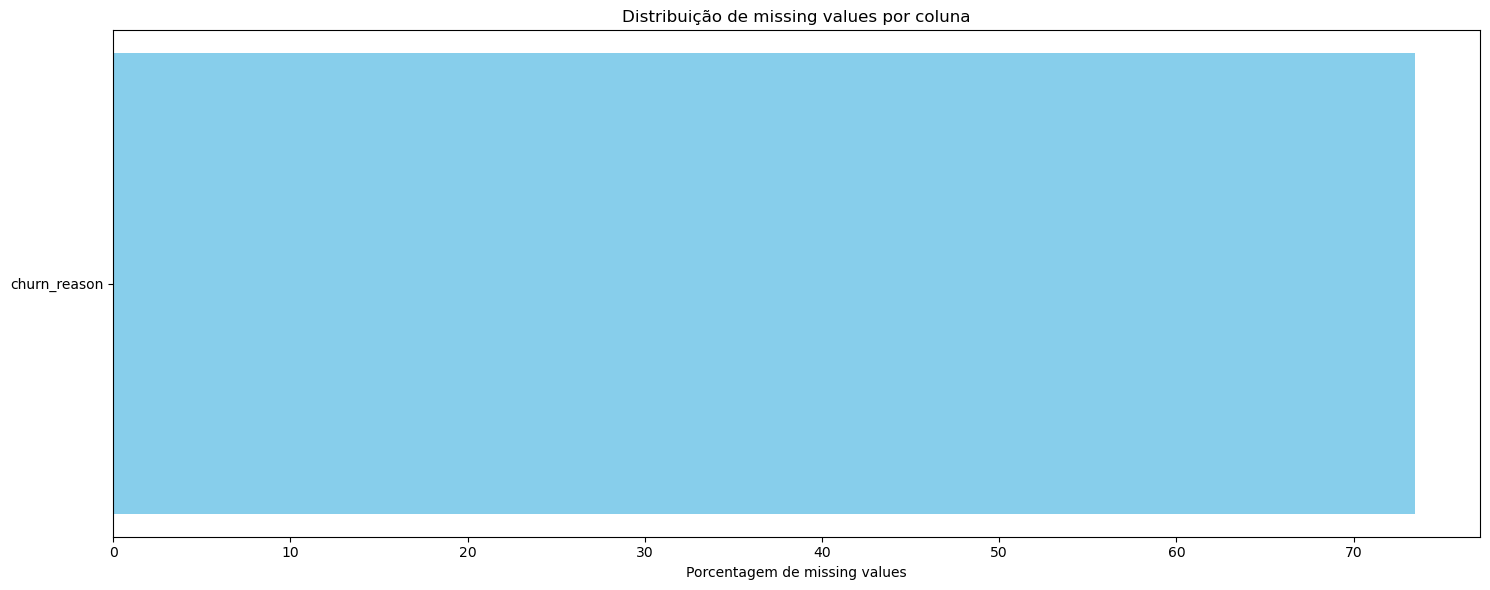

In [81]:
## Análise de missing values
print("===== Missing values =====")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_count': df.isnull().sum(),
    'Missing_Percentage':(df.isnull().sum()/len(df)*100).round(2)
})

missing_values = missing_values[missing_values['Missing_count']>0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)

# Visualização dos missing values
    plt.figure(figsize=(15,6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='skyblue')
    plt.xlabel('Porcentagem de missing values')
    plt.title('Distribuição de missing values por coluna')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum missing value detectado')

# 4. Análise da variável churn_value

### 4.1 Entendimento da distribuição da variável alvo e o balanceamento de classes

==== Distribuição da variável churn_value
Contagem: 
churn_value
0    5174
1    1869
Name: count, dtype: int64

Percentual: 
cliente churn (0): 73.46%
cliente nao churn (1): 26.54%


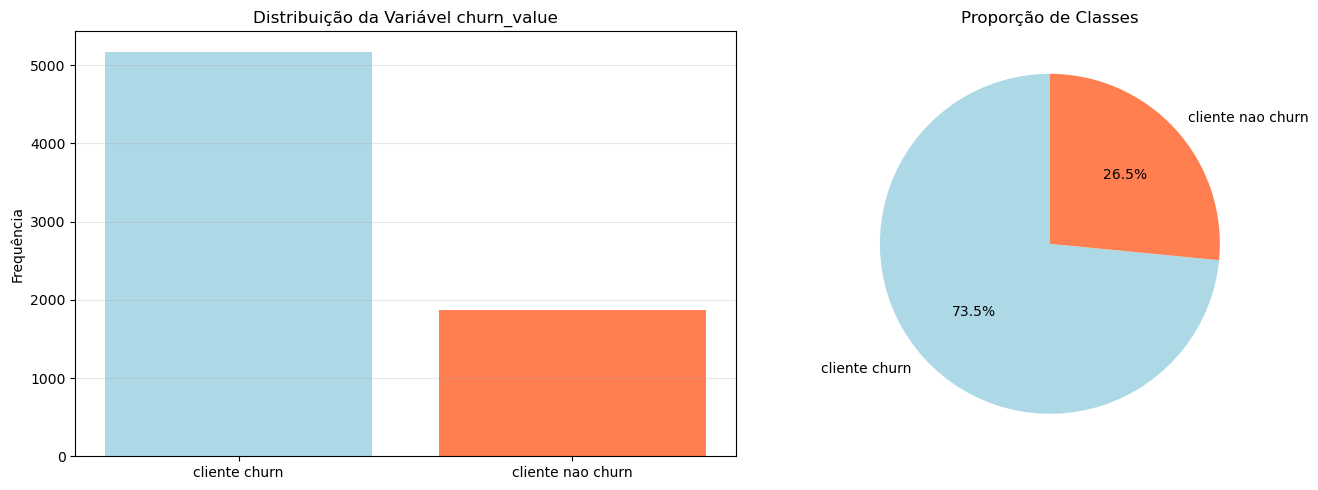


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [82]:
df['churn_value'] = (df['churn_value'] > 0).astype(int)

print("==== Distribuição da variável churn_value")

churn_value_counts = df['churn_value'].value_counts()
churn_value_percentages = df['churn_value'].value_counts(normalize=True) * 100


print("Contagem: ")
print(churn_value_counts)
print("\nPercentual: ")

for idx, pct in churn_value_percentages.items():
    label = "cliente churn" if idx == 0 else "cliente nao churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['cliente churn', 'cliente nao churn'], churn_value_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável churn_value')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(churn_value_counts.values, labels=['cliente churn', 'cliente nao churn'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = churn_value_counts.min() / churn_value_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")



Taxa de Churn Geral: 26.54%
Total de clientes que saíram (churners): 1869
Valor médio de Monthly Charges para clientes que saíram (churn): 73.02
Valor médio de Monthly Charges para clientes que ficaram (stay): 61.46

Taxa de churn por tipo de contrato:
contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64

AGREGAÇÃO: Internet Service x Phone Service

Contagem de clientes por combinação:
churn_label                       No   Yes   All
internet_service phone_service                  
DSL              No              512   170   682
                 Yes            1450   289  1739
Fiber optic      Yes            1799  1297  3096
No               Yes            1413   113  1526
All                             5174  1869  7043

Taxa de churn (%) por Internet Service e Phone Service:
internet_service  phone_service
DSL               No               24.93
                  Yes              16.62
Fiber optic       Yes              41.89
No

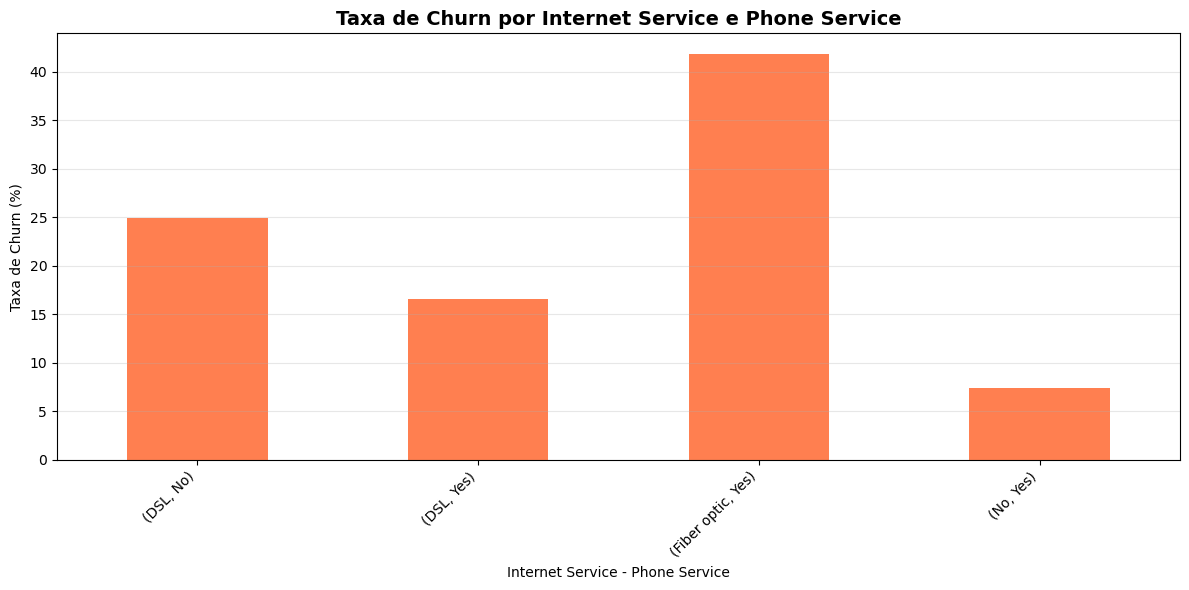

In [27]:
# 1. Volume: Taxa de Churn Geral
churn_rate = df['churn_label'].value_counts(normalize=True)['Yes'] * 100
total_churners = df[df['churn_label'] == 'Yes'].shape[0]
print(f"Taxa de Churn Geral: {churn_rate:.2f}%")
print(f"Total de clientes que saíram (churners): {total_churners}")


# 2. Valor: Monthly Charges (Quem sai vs. Quem fica)
df_loc_contract = df['contract'] == 'Month-to-month'
df_loc_churn_label_yes = df['churn_label'] == 'Yes'
avg_monthly_churn = df[df_loc_churn_label_yes & df_loc_contract]['monthly_charges'].mean()
print(f"Valor médio de Monthly Charges para clientes que saíram (churn): {avg_monthly_churn:.2f}")


df_loc_stay_label_no = df['churn_label'] == 'No'
avg_monthly_stay = df[df_loc_stay_label_no & df_loc_contract]['monthly_charges'].mean()
print(f"Valor médio de Monthly Charges para clientes que ficaram (stay): {avg_monthly_stay:.2f}")

# 3. Produto: Churn por Tipo de Contrato
contract_churn = pd.crosstab(df['contract'], df['churn_label'], normalize='index')['Yes']*100
print(f"\nTaxa de churn por tipo de contrato:")
print(contract_churn.round(2))

# 4. Agregação por Internet Service e Phone Service
print("\n" + "="*60)
print("AGREGAÇÃO: Internet Service x Phone Service")
print("="*60)

service_agg = pd.crosstab(
    index=[df['internet_service'], df['phone_service']], 
    columns=df['churn_label'], 
    margins=True
)
print("\nContagem de clientes por combinação:")
print(service_agg)

# Taxa de churn por internet_service e phone_service
service_churn_rate = pd.crosstab(
    index=[df['internet_service'], df['phone_service']], 
    columns=df['churn_label'], 
    normalize='index'
)['Yes'] * 100
print("\nTaxa de churn (%) por Internet Service e Phone Service:")
print(service_churn_rate.round(2))

# Visualização
fig, ax = plt.subplots(figsize=(12, 6))
service_churn_rate.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Taxa de Churn por Internet Service e Phone Service', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa de Churn (%)')
ax.set_xlabel('Internet Service - Phone Service')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

c:\Users\lara-\anaconda3\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


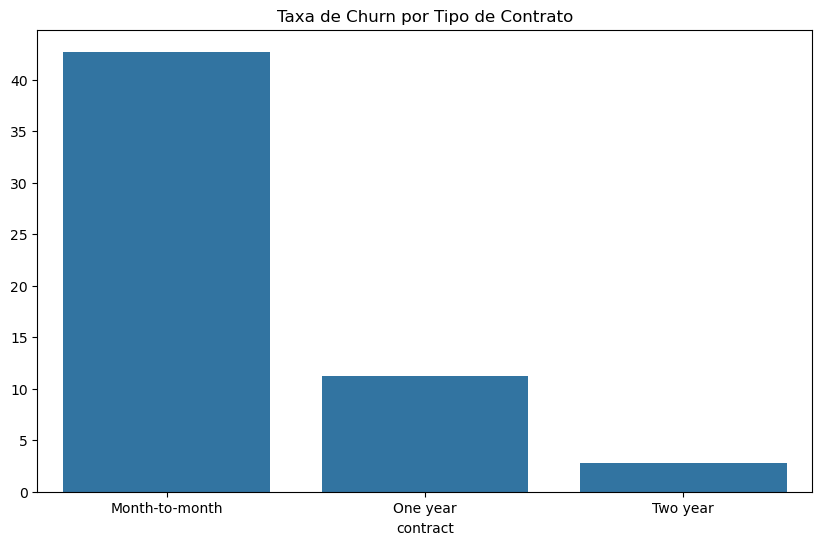

In [32]:
import mlflow

# Definir o experimento de análise inicial
mlflow.set_experiment("Projeto_Churn_Tech_Challenge")
# Define o banco de dados na raiz do projeto
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
 
with mlflow.start_run(run_name="Baseline_Analysis"):
    csv_path = "data/processed/dataset_tratado.parquet"
    dataset = mlflow.data.from_pandas(df, source=csv_path, name="Churn_Analysis_Base")
    
    mlflow.log_input(dataset, context="training")

    # Registrar métricas de negócio (Situation)
    mlflow.log_metric("churn_rate_percent", churn_rate)
    mlflow.log_metric("total_churn_count", total_churners)
    mlflow.log_metric("avg_revenue_lost_per_client", avg_monthly_churn)
    
    # Registrar padrões identificados como parâmetros
    mlflow.log_param("critical_product", "Fiber Optic")
    mlflow.log_param("critical_contract", "Month-to-month")

    # Salvar gráficos como artefatos (para o seu vídeo STAR)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=contract_churn.index, y=contract_churn.values)
    plt.title("Taxa de Churn por Tipo de Contrato")
    plt.savefig("churn_by_contract.png")
    
    # Enviar a imagem para o MLflow
    mlflow.log_artifact("churn_by_contract.png")

### 4.2 Análise de distribuição - Gender e Churn

Churn por Gênero:churn_value         0         1
gender                         
Female       0.730791  0.269209
Male         0.738397  0.261603


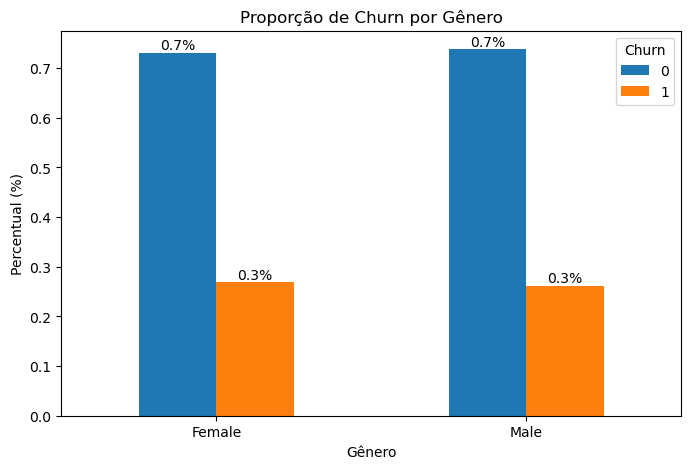

In [83]:
churn_gender = pd.crosstab(df['gender'], df['churn_value'], normalize='index')

print(F"Churn por Gênero:{churn_gender}")
ax = churn_gender.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Proporção de Churn por Gênero')
plt.ylabel('Percentual (%)')
plt.xlabel('Gênero')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()


### 4.3 Análise de distribuição - City e Churn

Churn por top 5 cidades com mais churn: churn_value            0          1
city                               
Los Angeles    70.491803  29.508197
Sacramento     75.925926  24.074074
San Diego      66.666667  33.333333
San Francisco  70.192308  29.807692
San Jose       74.107143  25.892857


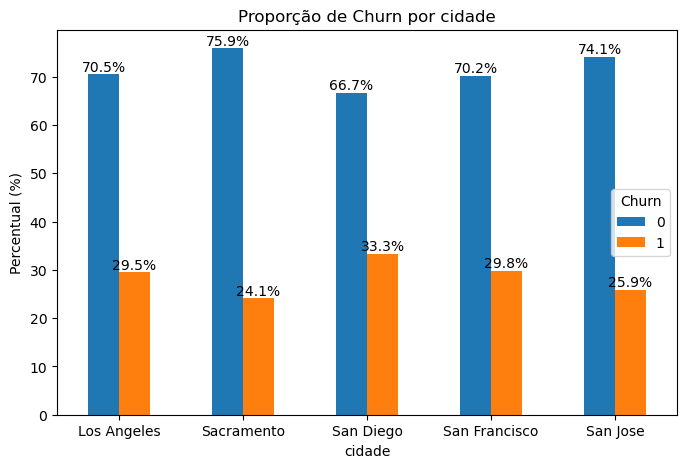

In [84]:
top_cities = df['city'].value_counts().head(5).index
df_top = df[df['city'].isin(top_cities)]

churn_city = pd.crosstab(df_top['city'], df_top['churn_value'], normalize='index') * 100

print(F"Churn por top 5 cidades com mais churn: {churn_city}")
ax = churn_city.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Proporção de Churn por cidade')
plt.ylabel('Percentual (%)')
plt.xlabel('cidade')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

### 4.3 Análise de distribuição - Contract e Churn

Churn por tipo contrato:churn_value         0         1
gender                         
Female       0.730791  0.269209
Male         0.738397  0.261603


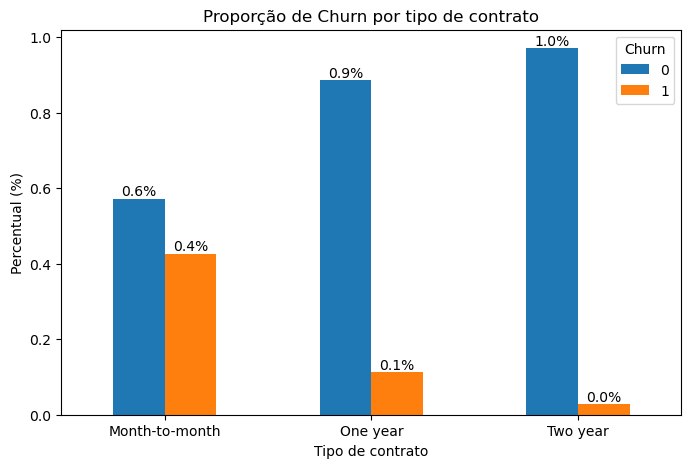

In [85]:
churn_contract = pd.crosstab(df['contract'], df['churn_value'], normalize='index')

print(F"Churn por tipo contrato:{churn_gender}")
ax = churn_contract.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Proporção de Churn por tipo de contrato')
plt.ylabel('Percentual (%)')
plt.xlabel('Tipo de contrato')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

### 4.4 Análise de distribuição - Tech Support e Churn

Churn por support:churn_value                 0         1
tech_support                           
No                   0.583645  0.416355
No internet service  0.925950  0.074050
Yes                  0.848337  0.151663


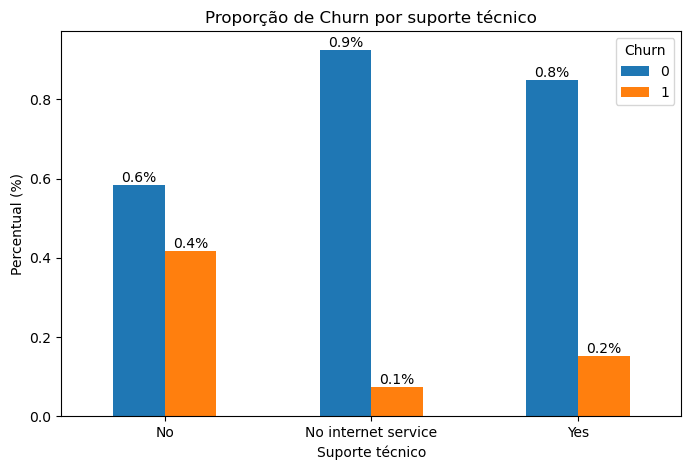

In [86]:
churn_support = pd.crosstab(df['tech_support'], df['churn_value'], normalize='index')

print(F"Churn por support:{churn_support}")
ax = churn_support.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Proporção de Churn por suporte técnico')
plt.ylabel('Percentual (%)')
plt.xlabel('Suporte técnico')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [87]:
df.head()

,customer_id,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,8844-TONUD,1,United States,California,Acampo,95220,"38.200231, -121.235034",38.200231,-121.235034,Male,...,Month-to-month,Yes,Mailed check,96.65,1162.85,Yes,1,75,5295,Attitude of service provider
1,1455-UGQVH,1,United States,California,Acampo,95220,"38.200231, -121.235034",38.200231,-121.235034,Male,...,Month-to-month,Yes,Electronic check,98.50,1037.75,Yes,1,91,4501,Lack of self-service on Website
2,9249-FXSCK,1,United States,California,Acampo,95220,"38.200231, -121.235034",38.200231,-121.235034,Female,...,One year,Yes,Credit card (automatic),111.25,5916.45,Yes,1,90,4861,Competitor offered more data
3,9063-ZGTUY,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Female,...,Month-to-month,Yes,Mailed check,19.40,1182.55,Yes,1,82,4221,Don't know
4,6397-JNZZG,1,United States,California,Adin,96006,"41.171578, -120.913161",41.171578,-120.913161,Female,...,Month-to-month,No,Credit card (automatic),55.55,2342.2,Yes,1,85,2573,Competitor offered higher download speeds


# Analise de Outlier

C:\Users\lara-\AppData\Local\Temp\ipykernel_26036\3014436887.py:15: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  col_zscore = np.abs(stats.zscore(df[col].dropna()))


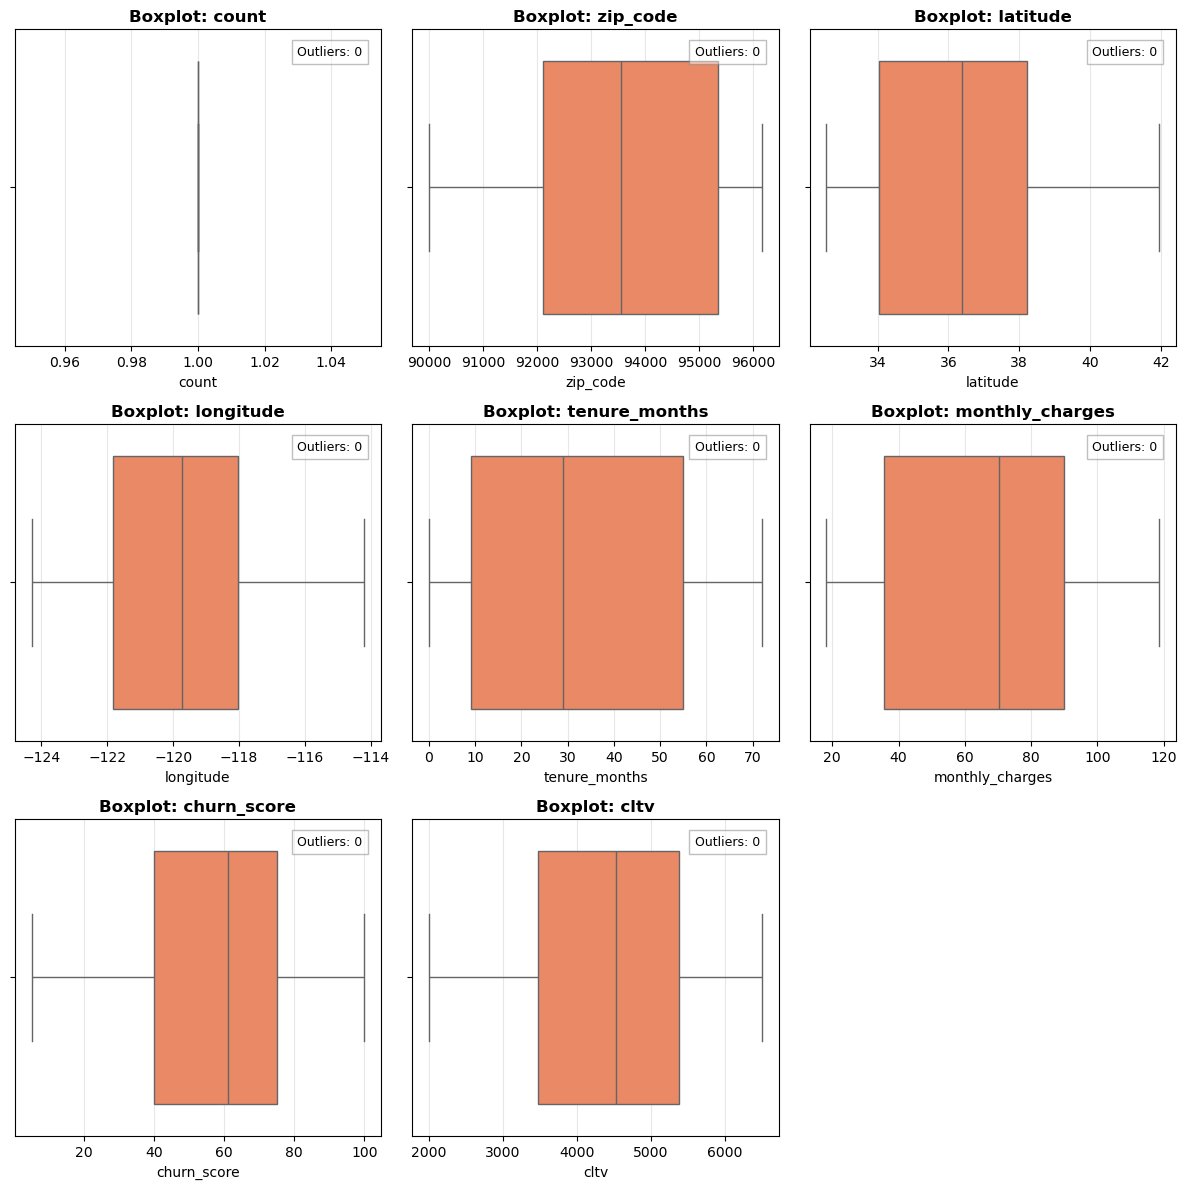

In [88]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['churn_value'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


# Analise de distribuição

=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

         Coluna  Skewness  Kurtosis Interpretação
          count     0.000     0.000        Normal
       zip_code    -0.251    -1.154        Normal
       latitude     0.304    -1.136        Normal
      longitude    -0.041    -1.136        Normal
  tenure_months     0.240    -1.387        Normal
monthly_charges    -0.221    -1.257        Normal
    churn_score    -0.090    -1.006        Normal
           cltv    -0.312    -0.934        Normal


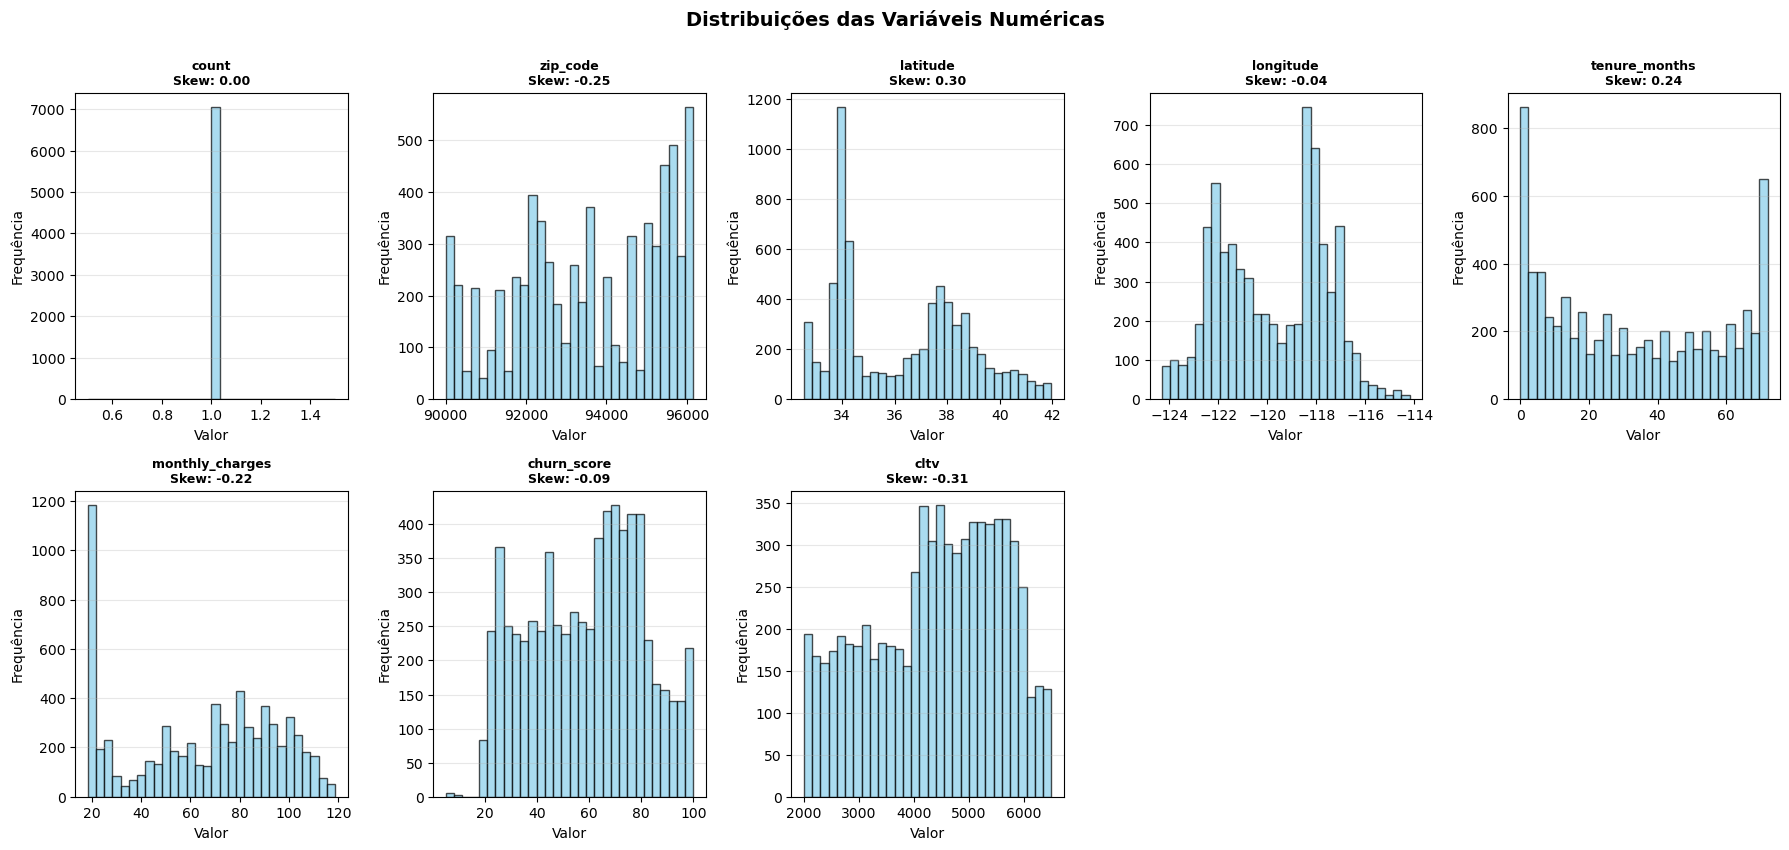

In [89]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Analise de correlações

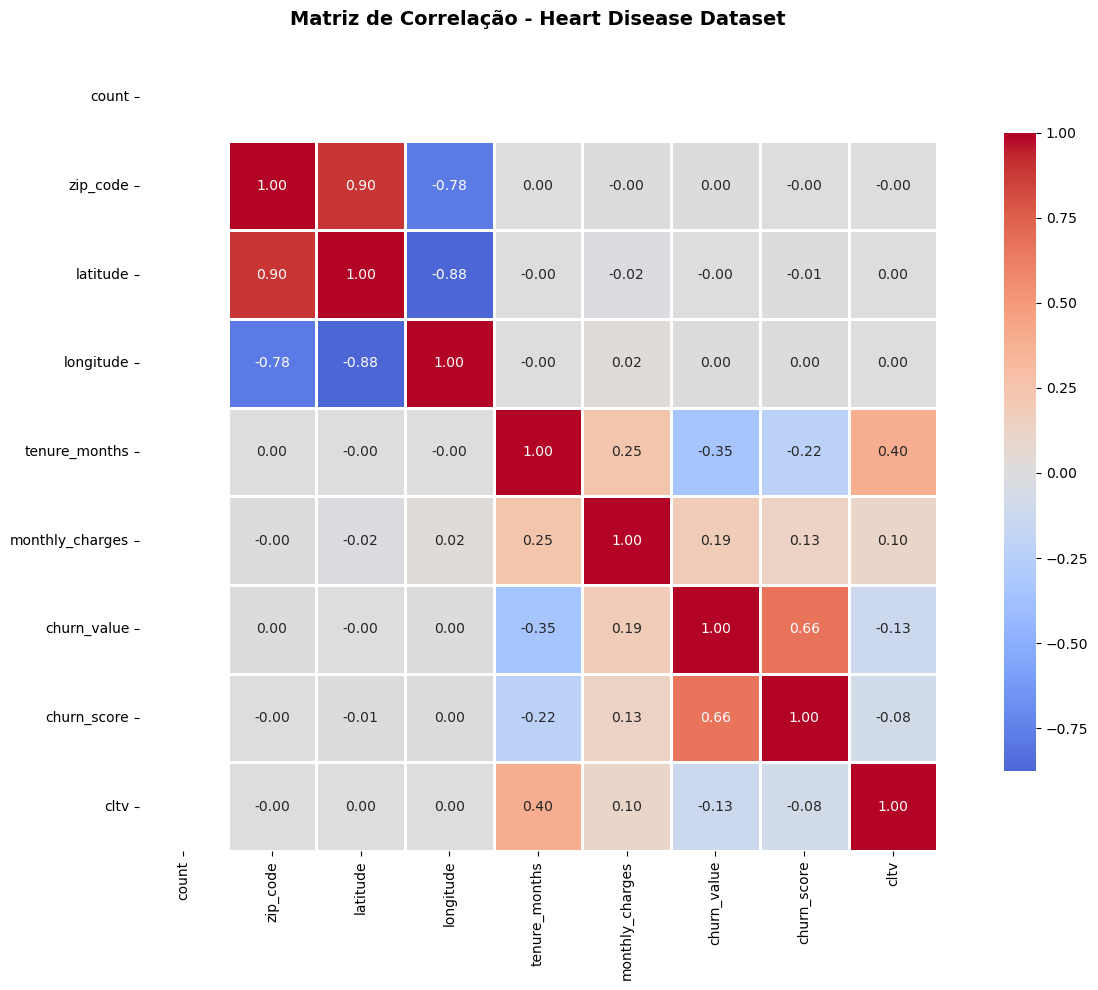

=== CORRELAÇÕES COM A VARIÁVEL churn_value ===

churn_value        1.000000
churn_score        0.664897
monthly_charges    0.193356
longitude          0.004594
zip_code           0.003346
latitude          -0.003384
cltv              -0.127463
tenure_months     -0.352229
count                   NaN
Name: churn_value, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

Feature 1 Feature 2  Correlação
 zip_code  latitude       0.896
 zip_code longitude      -0.784
 latitude longitude      -0.877

⚠️ Alta correlação entre features pode causar multicolinearidade!


In [90]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Heart Disease Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o churn_value
print("=== CORRELAÇÕES COM A VARIÁVEL churn_value ===\n")
churn_value_corr = corr_numeric['churn_value'].sort_values(ascending=False)
print(churn_value_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'churn_value' and corr_numeric.columns[j] != 'churn_value':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo churn_value)")

In [91]:
df.rename(columns={
            'CustomerID': 'customer_id',
            'Count': 'count',	
            'Country': 'country',	
            'State': 'state',
            'City': 'city',
            'Zip Code': 'zip_code',
            'Lat Long': 'lat_long',
            'Latitude': 'latitude',
            'Longitude': 'longitude',	
            'Gender': 'gender',
            'Senior Citizen': 'senior_citizen',
            'Partner': 'partner',	
            'Dependents': 'dependents',	
            'Tenure Months': 'tenure_months',	
            'Phone Service': 'phone_service',	
            'Multiple Lines': 'multiple_lines',	
            'Internet Service': 'internet_service',	
            'Online Security': 'online_security',	
            'Online Backup': 'online_backup',	
            'Device Protection': 'device_protection',	
            'Tech Support': 'tech_support',	
            'Streaming TV': 'streaming_tv',	
            'Streaming Movies': 'streaming_movies',	
            'Contract': 'contract',	
            'Paperless Billing': 'paperless_billing',	
            'Payment Method': 'payment_method',
            'Monthly Charges': 'monthly_charges',	
            'Total Charges': 'total_charges',	
            'Churn Label': 'churn_label',	
            'Churn Value': 'churn_value',	
            'Churn Score': 'churn_score',	
            'CLTV': 'cltv',	
            'Churn Reason': 'churn_reason'},
            inplace=True
)

In [92]:
print("=== TRATAMENTO DE MISSING VALUES ===\n")

# Copiar o dataframe original para preservar os dados
df_clean = df.copy()

# Imputação para variáveis categóricas: moda
cat_missing = ['churn_reason']

for col in cat_missing:
    if col in df_clean.columns:
        mode = df_clean[col].mode()[0]
        df_clean[col].fillna(mode, inplace=True)
        print(f"{col}: imputado com moda ('{mode}')")

print("\n✓ Tratamento de missing values concluído!")
print(f"Shape após imputação: {df_clean.shape}")
print("Valores ausentes restantes por coluna:")
print(df_clean.isnull().sum())

=== TRATAMENTO DE MISSING VALUES ===

churn_reason: imputado com moda ('Attitude of support person')

✓ Tratamento de missing values concluído!
Shape após imputação: (7043, 33)
Valores ausentes restantes por coluna:
customer_id          0
count                0
country              0
state                0
city                 0
zip_code             0
lat_long             0
latitude             0
longitude            0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure_months        0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn_label          0
churn_value          0
churn_score          0
cltv                 0
churn_reason         0
dtype: int64


C:\Users\lara-\AppData\Local\Temp\ipykernel_26036\1451679156.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(mode, inplace=True)


In [93]:
# Convertendo 'total_charges' para numérico e preenchendo NaN com a média
df_model = df_clean.drop(columns=['customer_id', 'zip_code', 'lat_long','latitude', 'longitude', 'churn_label', 'churn_score', 'cltv'])    
df_model['total_charges'] = pd.to_numeric(df_clean['total_charges'], errors='coerce')
df_model['total_charges'] = df_model['total_charges'].fillna(df_model['total_charges'].mean())

df_model.describe()

,count,tenure_months,monthly_charges,total_charges,churn_value
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,32.371149,64.761692,2283.300441,0.265370
std,0.0,24.559481,30.090047,2265.000258,0.441561
min,1.0,0.000000,18.250000,18.800000,0.000000
25%,1.0,9.000000,35.500000,402.225000,0.000000
50%,1.0,29.000000,70.350000,1400.550000,0.000000
75%,1.0,55.000000,89.850000,3786.600000,1.000000
max,1.0,72.000000,118.750000,8684.800000,1.000000


In [94]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   count              7043 non-null   int64  
 1   country            7043 non-null   object 
 2   state              7043 non-null   object 
 3   city               7043 non-null   object 
 4   gender             7043 non-null   object 
 5   senior_citizen     7043 non-null   object 
 6   partner            7043 non-null   object 
 7   dependents         7043 non-null   object 
 8   tenure_months      7043 non-null   int64  
 9   phone_service      7043 non-null   object 
 10  multiple_lines     7043 non-null   object 
 11  internet_service   7043 non-null   object 
 12  online_security    7043 non-null   object 
 13  online_backup      7043 non-null   object 
 14  device_protection  7043 non-null   object 
 15  tech_support       7043 non-null   object 
 16  streaming_tv       7043 

In [95]:
display(df_model.head())

,count,country,state,city,gender,senior_citizen,partner,dependents,tenure_months,phone_service,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason
0,1,United States,California,Acampo,Male,No,Yes,No,13,Yes,...,No,Yes,Yes,Month-to-month,Yes,Mailed check,96.65,1162.85,1,Attitude of service provider
1,1,United States,California,Acampo,Male,No,Yes,No,10,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.50,1037.75,1,Lack of self-service on Website
2,1,United States,California,Acampo,Female,No,No,No,52,Yes,...,Yes,Yes,Yes,One year,Yes,Credit card (automatic),111.25,5916.45,1,Competitor offered more data
3,1,United States,California,Adelanto,Female,No,Yes,No,61,Yes,...,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.40,1182.55,1,Don't know
4,1,United States,California,Adin,Female,Yes,Yes,No,43,No,...,No,Yes,Yes,Month-to-month,No,Credit card (automatic),55.55,2342.20,1,Competitor offered higher download speeds


In [96]:
df_model.to_parquet('../data/processed/dataset_tratado.parquet', index=False)